### Importar las bibliotecas

In [ ]:
from io import StringIO

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
from shapely.geometry import Polygon


### Importo datos con API

In [109]:
# Importo los datos

url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

# pido un box que incluya todo el territorio argentino

params = {
    "format": "csv",
    "starttime": "2016-09-15",
    "endtime": "2026-09-15",
    "minlatitude": -90,
    "maxlatitude": -21.7,
    "minlongitude": -75,
    "maxlongitude": -25,
    "limit": 20000
}

response = requests.get(url, params=params)
response.raise_for_status()



In [110]:
# Genero DataFrame

df = pd.read_csv(StringIO(response.text))

### Chequeo que esten aprox los datos antes de guardar el raw

In [111]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])


Filas: 10793
Columnas: 22


In [112]:
df.head(3)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-09-14T05:03:12.877Z,-24.1313,-66.9986,189.041,4.4,mb,35.0,77.0,2.572,0.66,...,2026-09-14T06:21:54.040Z,"69 km W of San Antonio de los Cobres, Argentina",earthquake,3.33,13.010,0.149,13.0,reviewed,us,us
1,2026-09-13T19:40:25.248Z,-26.1559,-66.5753,10.000,4.7,mb,43.0,54.0,3.508,0.72,...,2026-09-13T20:22:09.040Z,"60 km W of Cafayate, Argentina",earthquake,6.22,1.890,0.093,35.0,reviewed,us,us
2,2026-09-13T12:36:14.144Z,-33.3311,-72.5473,10.000,3.9,mwr,40.0,77.0,0.815,1.02,...,2026-09-13T13:08:44.040Z,"90 km WNW of Cartagena, Chile",earthquake,4.36,1.839,0.053,34.0,reviewed,us,us


In [113]:
# Guardo datos originales en .csv

df.to_csv("../data/raw/sismos_usgs.csv", index=False)


### Visualización general 1

**Fuente:** https://www.ign.gob.ar/NuestrasActividades/InformacionGeoespacial/CapasSIG


In [114]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]), crs="EPSG:4326"
)

In [115]:
# leo archivo SHP de Sudamerica(Poligono) y Argentina(Linea) del IGN para grafico

ign_sudam = gpd.read_file("../data/raw/geodata/referencias.shp")
ign_arg   = gpd.read_file("../data/raw/geodata/limites.shp")


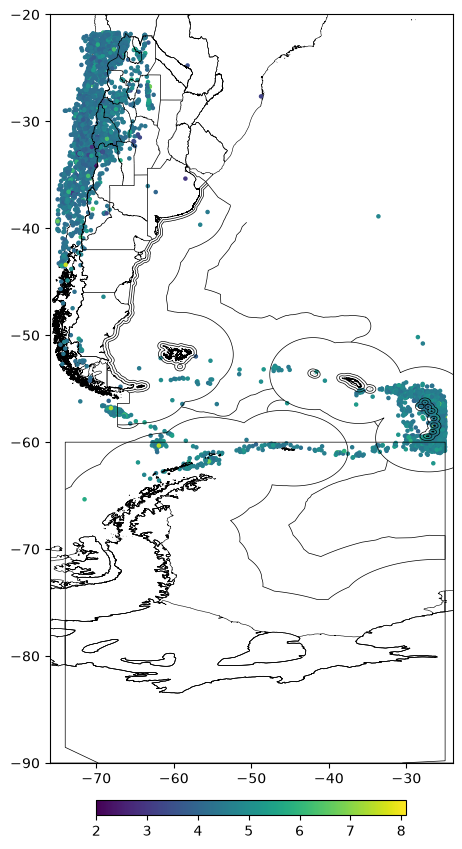

In [116]:

fig, ax = plt.subplots(figsize=(10, 12))

ign_sudam.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.4
)

ign_arg.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

gdf.plot(
    ax=ax,
    column="mag",
    cmap="viridis",
    markersize=5,
    legend=True,
    legend_kwds={
        "orientation": "horizontal",
        "shrink": 0.4,
        "pad": 0.04
    }
)

# Zoom sobre Argentina y alrededores
ax.set_xlim(-76, -24)
ax.set_ylim(-90, -20)

plt.show()

### Me quedo solo con los datos en Argentina generando un polígono completo del país.

In [117]:

# leo archivo SHP de provincias y plataforma continental del IGN

ign_provincias = gpd.read_file("../data/raw/geodata/provinciaPolygon.shp")
ign_plataforma = gpd.read_file("../data/raw/geodata/plataforma_continentalPolygon.shp")


# armo el sector antártico

coordenadas_antartida = [
    (-74.0, -60.0),  # Esquina Noroeste
    (-25.0, -60.0),  # Esquina Noreste
    (-25.0, -90.0),  # Polo Sur (Límite Este)
    (-74.0, -90.0),  # Polo Sur (Límite Oeste)
    (-74.0, -60.0)   # Cierre
]

poligono_antartico = Polygon(coordenadas_antartida)

# Uno las 3 geometrías en un solo polígono

poligono_nacional = (
    ign_provincias.union_all()
    .union(ign_plataforma.union_all())
    .union(poligono_antartico)
)



In [118]:
# filtro los puntos que se ubiquen dentro del polígono

gdf_arg = gdf[gdf.geometry.within(poligono_nacional)]

df_arg = pd.DataFrame(gdf_arg.drop(columns='geometry'))


### Visualizacion general 2

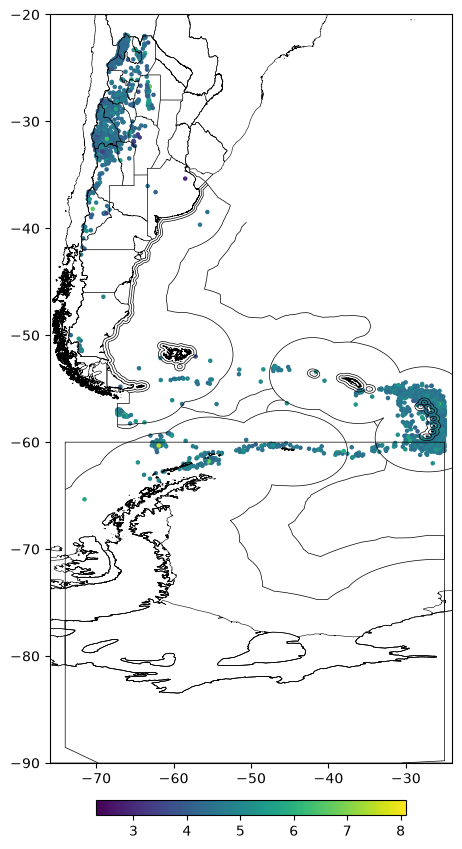

In [119]:
# Visualización de los sismos en Argentina entre 2016 y 2026

fig, ax = plt.subplots(figsize=(10, 12))

ign_sudam.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.4
)

ign_arg.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

gdf_arg.plot(
    ax=ax,
    column="mag",
    cmap="viridis",
    markersize=5,
    legend=True,
    legend_kwds={
        "orientation": "horizontal",
        "shrink": 0.4,
        "pad": 0.04
    }
)

# Zoom sobre Argentina y alrededores
ax.set_xlim(-76, -24)
ax.set_ylim(-90, -20)

plt.show()

### Análisis de datos

In [120]:
print("Filas:", df_arg.shape[0])
print("Columnas:", df_arg.shape[1])


Filas: 6429
Columnas: 22


In [ ]:
df_arg.head(3)

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-09-14T05:03:12.877Z,-24.1313,-66.9986,189.041,4.4,mb,35.0,77.0,2.572,0.66,...,2026-09-14T06:21:54.040Z,"69 km W of San Antonio de los Cobres, Argentina",earthquake,3.33,13.010,0.149,13.0,reviewed,us,us
1,2026-09-13T19:40:25.248Z,-26.1559,-66.5753,10.000,4.7,mb,43.0,54.0,3.508,0.72,...,2026-09-13T20:22:09.040Z,"60 km W of Cafayate, Argentina",earthquake,6.22,1.890,0.093,35.0,reviewed,us,us
3,2026-09-12T11:05:46.433Z,-56.2951,-26.9013,102.352,4.9,mb,30.0,67.0,5.836,0.79,...,2026-09-23T07:20:17.040Z,South Sandwich Islands region,earthquake,12.33,7.797,0.106,28.0,reviewed,us,us


In [122]:
df_arg.info()

<class 'pandas.DataFrame'>
Index: 6429 entries, 0 to 10792
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             6429 non-null   str    
 1   latitude         6429 non-null   float64
 2   longitude        6429 non-null   float64
 3   depth            6429 non-null   float64
 4   mag              6429 non-null   float64
 5   magType          6429 non-null   str    
 6   nst              2556 non-null   float64
 7   gap              6421 non-null   float64
 8   dmin             6421 non-null   float64
 9   rms              6427 non-null   float64
 10  net              6429 non-null   str    
 11  id               6429 non-null   str    
 12  updated          6429 non-null   str    
 13  place            6429 non-null   str    
 14  type             6429 non-null   str    
 15  horizontalError  6427 non-null   float64
 16  depthError       6429 non-null   float64
 17  magError         6202 non-nul

#### analisis de nulos

In [123]:
nulos = df_arg.isna().sum()
nulos[nulos>0]

nst                3873
gap                   8
dmin                  8
rms                   2
horizontalError       2
magError            227
magNst              229
dtype: int64

In [124]:
# Análisis porcentual de nulos

((nulos[nulos>0]/df_arg.shape[0])*100).round(3)

nst                60.243
gap                 0.124
dmin                0.124
rms                 0.031
horizontalError     0.031
magError            3.531
magNst              3.562
dtype: float64

nst presenta aproximadamente un 60 % de valores faltantes, por lo que se propone excluirla del análisis posterior. Para las restantes variables, los faltantes representan una proporción reducida y se propone imputarlos mediante la mediana durante la etapa de transformación.

#### analisis de duplicados

In [125]:
id = df_arg["id"].value_counts()
id[id>1]

Series([], Name: count, dtype: int64)

In [126]:
df_arg.duplicated().value_counts()

False    6429
Name: count, dtype: int64

No existen filas ni identificadores duplicados.

#### Análisis variables object

In [127]:

df_arg["magType"].value_counts()

magType
mb       5648
mww       458
mwr       267
ml         45
md          6
mw          2
mb_lg       2
mwb         1
Name: count, dtype: int64

esta está ok

In [128]:
df_arg["updated"].value_counts()

updated
2024-08-16T21:59:24.040Z    18
2026-01-01T23:11:08.040Z    11
2025-07-12T16:30:42.040Z    11
2021-10-29T14:47:05.040Z    11
2021-10-29T14:46:49.040Z    11
                            ..
2016-12-12T23:01:28.040Z     1
2025-12-22T17:17:54.106Z     1
2016-12-12T23:01:27.040Z     1
2016-12-12T23:01:26.040Z     1
2025-12-22T17:17:51.214Z     1
Name: count, Length: 4762, dtype: int64

In [129]:
df_arg["time"].value_counts()

time
2026-09-14T05:03:12.877Z    1
2026-09-13T19:40:25.248Z    1
2026-09-12T11:05:46.433Z    1
2026-09-09T10:06:57.170Z    1
2026-09-08T06:50:46.470Z    1
                           ..
2016-09-17T01:02:21.620Z    1
2016-09-16T12:04:39.700Z    1
2016-09-15T04:50:34.110Z    1
2016-09-15T02:37:59.150Z    1
2016-09-15T01:06:30.870Z    1
Name: count, Length: 6429, dtype: int64

Las columnas "updated" y "time" deberían transformarse a tipo DateTime

In [130]:
df_arg["status"].value_counts()

status
reviewed    6429
Name: count, dtype: int64

In [131]:
df_arg["type"].value_counts()

type
earthquake    6429
Name: count, dtype: int64

In [132]:
df_arg["net"].value_counts()

net
us        6427
iscgem       2
Name: count, dtype: int64

In [133]:
df_arg["locationSource"].value_counts()

locationSource
us        6421
sja          4
iscgem       2
guc          2
Name: count, dtype: int64

In [134]:
df_arg["magSource"].value_counts()

magSource
us        6205
guc        216
sja          6
iscgem       2
Name: count, dtype: int64

Tanto la columna "type" como "status" tienen una sola categoría por lo que no aportan información al proyecto, se propone descartarlas.

Lo mismo para las otras, mas del 95% de los datos son de una sola categoría.

#### analisis de variables numericas

In [135]:
df_arg.describe().round(3)

,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,6429.000,6429.000,6429.000,6429.000,2556.000,6421.000,6421.000,6427.000,6427.000,6429.000,6202.000,6200.000
mean,-45.516,-45.238,90.145,4.589,42.096,86.642,5.387,0.752,9.494,5.430,0.136,28.404
std,15.800,19.740,94.041,0.395,35.188,40.159,4.689,0.234,3.028,3.864,0.069,36.064
min,-65.344,-73.275,1.000,2.300,7.000,12.000,0.041,0.090,1.500,0.600,0.022,1.000
25%,-58.759,-66.936,10.000,4.300,21.000,58.000,1.615,0.590,7.300,1.900,0.089,11.000
50%,-55.850,-30.820,43.330,4.500,30.000,79.000,4.844,0.730,9.420,4.900,0.123,18.000
75%,-24.919,-26.055,167.650,4.800,51.000,107.000,7.461,0.900,11.570,7.800,0.164,33.000
max,-21.880,-25.002,626.010,8.100,466.000,292.000,32.456,2.480,28.300,32.700,0.539,663.000


In [136]:
df_arg['mag'].value_counts().sort_index()

mag
2.30      1
3.00      2
3.30      5
3.40      6
3.50      1
3.60      1
3.70      4
3.80     13
3.90     25
4.00    177
4.10    261
4.20    523
4.30    729
4.40    817
4.50    912
4.60    770
4.70    503
4.80    270
4.90    394
5.00    309
5.06      1
5.10    212
5.18      1
5.20    139
5.30     89
5.40     58
5.50     46
5.60     47
5.70     35
5.80     10
5.90     11
6.00     13
6.10     10
6.20      6
6.30      4
6.40     10
6.50      3
6.60      3
6.70      1
6.80      2
6.90      1
7.50      2
7.60      1
8.10      1
Name: count, dtype: int64

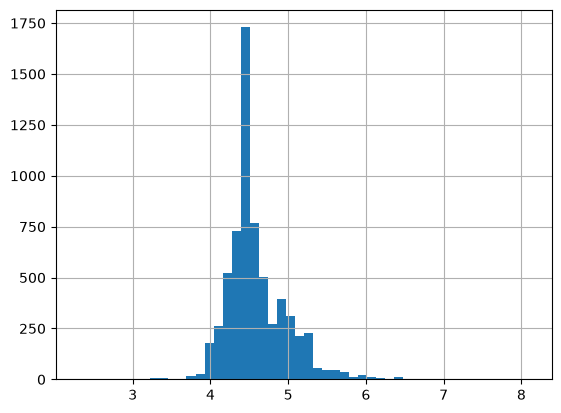

In [137]:
df_arg['mag'].hist(bins= 50)
plt.show()

Hay dos valores que llaman la atención por tener dos decimales de precisión, los analizo por separado.

In [138]:
index1 = df_arg[df_arg['mag']==5.06].index

In [139]:
index2 = df_arg[df_arg['mag']==5.18].index

In [140]:
df_arg.loc[index1]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
4846,2021-12-04T04:32:02.340Z,-59.762,-29.666,10.0,5.06,mw,NaN,NaN,NaN,NaN,...,2025-12-22T22:21:35.177Z,South Sandwich Islands region,earthquake,NaN,25.0,0.1,NaN,reviewed,iscgem,iscgem


In [141]:
df_arg.loc[index2]

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
6304,2021-03-14T14:09:13.950Z,-59.303,-31.041,10.0,5.18,mw,NaN,NaN,NaN,NaN,...,2025-12-22T18:55:19.233Z,Scotia Sea,earthquake,NaN,25.0,0.1,NaN,reviewed,iscgem,iscgem


miro que columnas tienen Na:

In [142]:
aux1 = df_arg.loc[index1].isna().sum()
aux1[aux1>0]

nst                1
gap                1
dmin               1
rms                1
horizontalError    1
magNst             1
dtype: int64

In [143]:
aux2 = df_arg.loc[index2].isna().sum()
aux2[aux2>0]

nst                1
gap                1
dmin               1
rms                1
horizontalError    1
magNst             1
dtype: int64

Se identificaron dos registros con valores de magnitud que resultan atípicos respecto del resto del conjunto de datos. Además, ambos presentan valores faltantes simultáneamente en nst, gap, dmin, rms, horizontalError y magNst, siendo estas variables de calidad. Al no poder evaluar la confiabilidad de las mediciones se recomienda excluir ambos registros del análisis posterior.

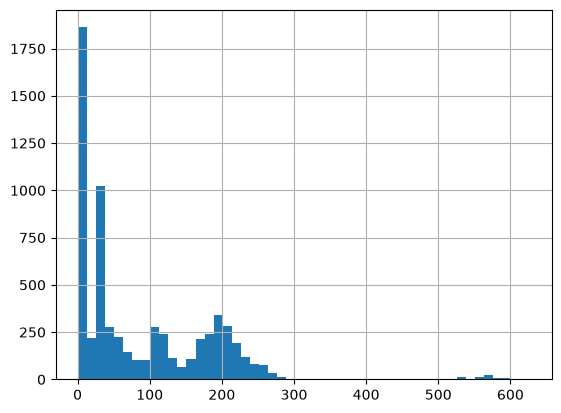

In [144]:
df_arg['depth'].hist(bins= 50)
plt.show()

En este caso, los valores que se observan entre 500 y 600 km de profundidad, aunque puedan parecer outliers, no lo son. Este salto se debe a la ductilidad de la placa tectónica entre los 300 y 500 km de profundidad que genera un "vacío" de sismos.

### Visualizacion general 3

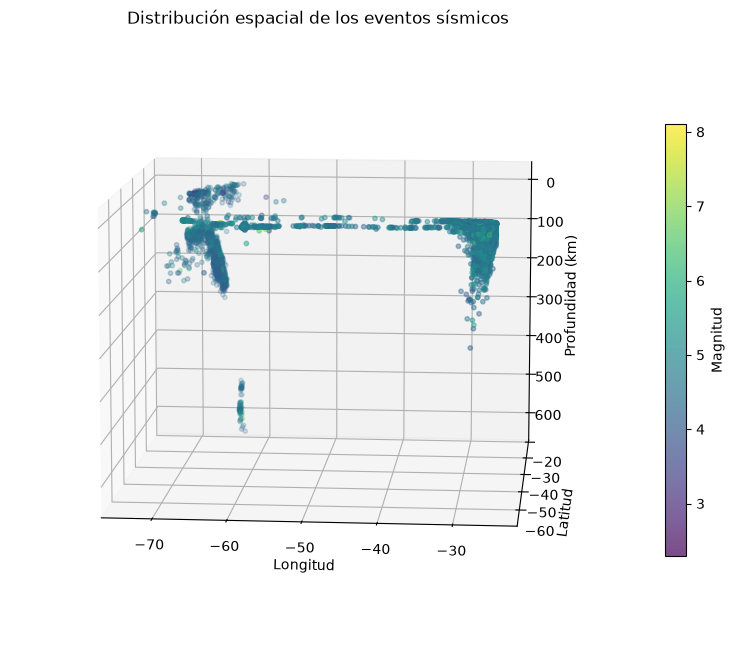

In [145]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_arg['longitude'],
    df_arg['latitude'],
    df_arg['depth'],
    c=df_arg['mag'],
    cmap='viridis',
    s=10,
    alpha=0.7
)

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_zlabel('Profundidad (km)')

ax.invert_zaxis()

ax.view_init(elev=10, azim=-85)

ax.set_title('Distribución espacial de los eventos sísmicos')

fig.colorbar(
    scatter,
    ax=ax,
    label='Magnitud',
    shrink=0.7
)

plt.show()

En resumen se deberían hacer los siguientes cambios en la etapa de transformación:

* Descartar las columnas: "nst", "net", "type", "status", "locationSource", "magSource".
* Descartar las filas de índice [4846] y [6304].
* Transformar las columnas "time" y "updated" a tipo DateTime.
* Rellenar los valores Na de las variables "gap", "dmin", "rms", "horizontalError", "magError", "magNst" con las medianas correspondientes.
* Crear columnas nuevas a partir de la variable "time".

Más informacion sobre las variables:

https://earthquake.usgs.gov/data/comcat/data-eventterms.php#nst

https://earthquake.usgs.gov/earthquakes/feed/v1.0/csv.php